# HOG trasform

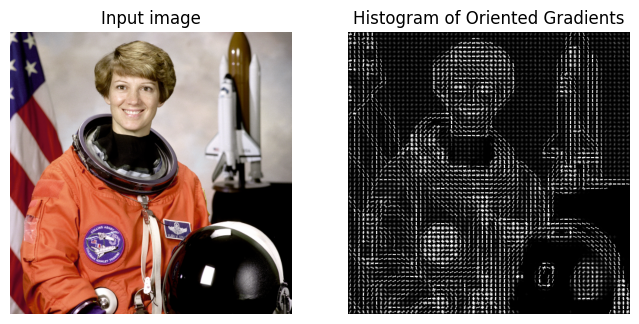

In [ ]:
import matplotlib.pyplot as plt  # for visualization
from skimage.feature import hog  # importing HOG (Histogram of Oriented Gradients), mainly used for object detection
from skimage import data, exposure  # importing sample images and exposure from skimage

image = data.astronaut()  # importing the astronaut sample image from skimage

# Computing the HOG features and visualization image
fd, hog_image = hog(
    image,  # input image
    orientations=8,  # number of gradient bins
    pixels_per_cell=(8, 8),  # size of the cell in pixels ----- Observation ---> Using (8,8) for pixels_per_cell captures finer details, preserving local edges and textures better than (16,16).
    cells_per_block=(1, 1),  # number of cells per block
    visualize=True,  # enable visualization
    channel_axis=-1,  # specify channel axis for color images
)

# Creating a figure with two subplots for displaying the input and HOG images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')  # Hiding the axes for better visualization
ax1.imshow(image, cmap=plt.cm.gray)  # Displaying the original image
ax1.set_title('Input image')  # Setting title for the input image

# Rescaling the HOG image for better visualization
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')  # Hiding the axes for better visualization
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)  # Displaying the HOG features image
ax2.set_title('Histogram of Oriented Gradients')  # Setting title for HOG visualization

plt.show()  # Displaying the plots

### Experiment with different parameters

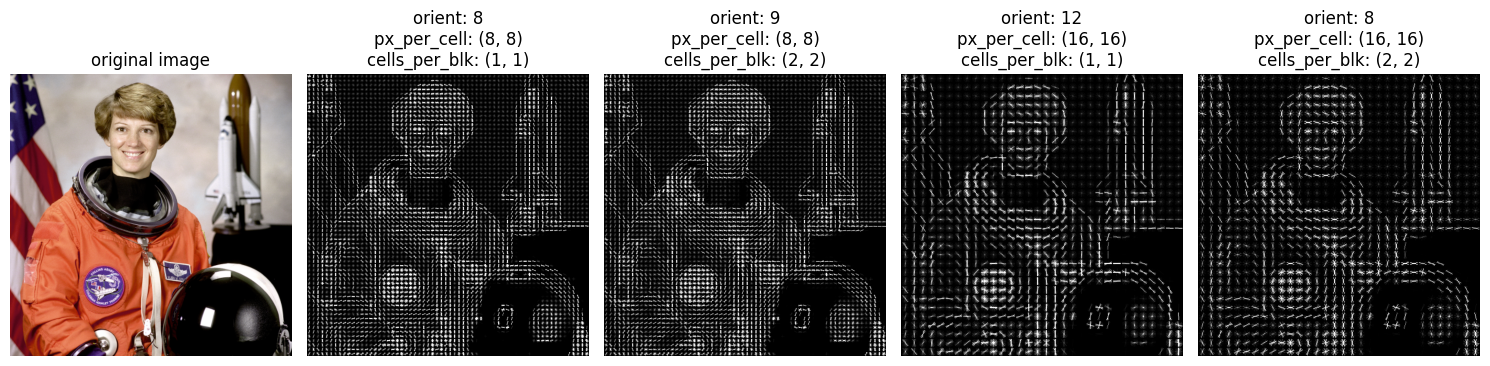

In [ ]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import data, exposure

image = data.astronaut()  # loading the astronaut image

# different parameter combinations to test
params = [
    {"orientations": 8, "pixels_per_cell": (8, 8), "cells_per_block": (1, 1)},
    {"orientations": 9, "pixels_per_cell": (8, 8), "cells_per_block": (2, 2)},
    {"orientations": 12, "pixels_per_cell": (16, 16), "cells_per_block": (1, 1)},
    {"orientations": 8, "pixels_per_cell": (16, 16), "cells_per_block": (2, 2)},
]

fig, axes = plt.subplots(1, len(params) + 1, figsize=(15, 5), sharex=True, sharey=True)

# display original image
axes[0].imshow(image, cmap=plt.cm.gray)
axes[0].set_title("original image")
axes[0].axis("off")

# compute and display HOG features for different parameter combinations
for i, param in enumerate(params):
    fd, hog_image = hog(
        image,
        orientations=param["orientations"],
        pixels_per_cell=param["pixels_per_cell"],
        cells_per_block=param["cells_per_block"],
        visualize=True,
        channel_axis=-1,
    )

    # rescale for better visualization
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    # display the HOG image
    title = f"orient: {param['orientations']}\npx_per_cell: {param['pixels_per_cell']}\ncells_per_blk: {param['cells_per_block']}"
    axes[i + 1].imshow(hog_image_rescaled, cmap=plt.cm.gray)
    axes[i + 1].set_title(title)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()


## **Observation of HOG Feature Extraction**  

### **Effects of Different Parameters**  

#### **1. `orientations=8`, `pixels_per_cell=(8,8)`, `cells_per_block=(1,1)`**  
- Captures fine details and local textures.  
- Good for detecting smaller patterns.  
- **Computational cost:** High due to more granular features.  

#### **2. `orientations=9`, `pixels_per_cell=(8,8)`, `cells_per_block=(2,2)`**  
- Retains sharpness but slightly reduces noise sensitivity.  
- Better feature grouping.  
- **Computational cost:** Moderate, balances detail and efficiency.  

#### **3. `orientations=12`, `pixels_per_cell=(16,16)`, `cells_per_block=(1,1)`**  
- Captures larger patterns but loses fine details.  
- Good for detecting overall shapes.  
- **Computational cost:** Lower, fewer feature vectors to process.  

#### **4. `orientations=8`, `pixels_per_cell=(16,16)`, `cells_per_block=(2,2)`**  
- Focuses on broad shapes rather than fine textures.  
- Less noise but sacrifices detail.  
- **Computational cost:** Fastest but less informative for small objects.  

### **Key Takeaways**  
- **Smaller pixels per cell (8,8)** → More detail, higher computation.  
- **Larger pixels per cell (16,16)** → Less detail, faster processing.  
- **More orientations (12)** → Captures more edge directions but increases computation.  
- **Larger cells per block (2,2)** → Better feature normalization, handles lighting changes well.  

### **Computational Impact**  
- Higher resolution features → **Better accuracy but slower processing**.  
- Larger cells and fewer orientations → **Faster but loses fine details**.  

Balancing **feature quality** and **computational efficiency** is crucial in object detection tasks like **face and pedestrian recognition**.